# Naive Bayes

### Table of contents
0. [Introduction](#0.-Introduction)
1. [A tiny dataset, by hand](#1.-A-tiny-dataset,-by-hand)
2. [Setup](#2.-Setup)
3. [Naive Bayes](#3.-Naive-Bayes)
4. [Summary](#4.-Summary)

## 0. Introduction

The last new model this course covers, and a purely probabilistic one: Naive Bayes applies **Bayes' theorem** with a simplifying assumption: every feature is conditionally independent given the class. Rarely true in reality, which is exactly why the assumption, and the model, is called naive, but it works surprisingly well anyway, especially on text, the classic spam-filter algorithm.

This is notebook 4 of 5 for the week.

## 1. A tiny dataset, by hand

8 emails as counts over 3 words, half spam and half ham.

In [1]:
import numpy as np

vocab_toy = ["free", "money", "meeting"]
X_nb_toy = np.array([
    [2, 1, 0], [1, 1, 0], [3, 0, 0], [1, 2, 0],  # spam
    [0, 0, 1], [0, 0, 2], [1, 0, 1], [0, 1, 1],  # ham
])
y_nb_toy = np.array(["spam"] * 4 + ["ham"] * 4)
new_email = np.array([[2, 1, 0]])  # "free free money"

Naive Bayes scores each class as `P(class) * P(email | class)`: how common the class is alone (the **prior**) times how well the email's words fit that class (the **likelihood**). Higher score wins.

`P(email | class)` is never one mysterious number: the naive assumption treats every word as independent given the class, so it breaks into a plain product of per-word probabilities, hence the name.

By hand, for `"free free money"` (word `free` shows up 2 times, `money` 1 time) against spam (`free=7, money=4, meeting=0` in training, 11 words total, 4 of 8 emails are spam):

- **Prior**: `P(spam) = 4/8 = 0.5`

- **Likelihood per word**, Laplace-smoothed (add 1 to the count, add the vocabulary size to the total, so a never-seen word does not zero out the whole product): `P(free|spam) = (7+1)/(11+3) ≈ 0.57`, `P(money|spam) = (4+1)/(11+3) ≈ 0.36`
- **Combine, once per word occurrence**: `free` shows up 2 times in the email and `money` 1 time, so each probability gets multiplied in that many times: `P(spam) * P(free|spam)^2 * P(money|spam)^1 = 0.5 * 0.57^2 * 0.36 ≈ 0.058`
- **Same thing, in log form** (safer for tiny numbers, `log(a*b) = log(a) + log(b)`), one line per word:
  - `free`, seen 2 times: `2 * log(0.57)`
  - `money`, seen 1 time: `1 * log(0.36)`
  - total: `log(0.058) = log(0.5) + 2 * log(0.57) + 1 * log(0.36)`

Same steps for ham (`free=1, money=1, meeting=5`, 7 total) give `≈ 0.004`. Spam wins by a wide margin, and that is the entire algorithm; the code below does this same bookkeeping for all 3 words and both classes at once.

Same numbers, computed for every word and both classes at once:

In [2]:
import math

classes = ["spam", "ham"]
priors = {c: (y_nb_toy == c).sum() / len(y_nb_toy) for c in classes}
word_counts = {c: X_nb_toy[y_nb_toy == c].sum(axis=0) for c in classes}
word_totals = {c: word_counts[c].sum() for c in classes}
priors, word_counts, word_totals

({'spam': np.float64(0.5), 'ham': np.float64(0.5)},
 {'spam': array([7, 4, 0]), 'ham': array([1, 1, 5])},
 {'spam': np.int64(11), 'ham': np.int64(7)})

In the code, `xi` is exactly that per-word count from above (`2` for `free`, `1` for `money`, `0` for `meeting`): each word's log-probability gets multiplied by its own `xi` before summing, the same `2 * log(...) + 1 * log(...)` computed by hand just now:

In [3]:
def log_score(c, x):
    counts, total = word_counts[c], word_totals[c]
    v = len(vocab_toy)
    log_likelihood = sum(xi * math.log((counts[i] + 1) / (total + v)) for i, xi in enumerate(x))
    return math.log(priors[c]) + log_likelihood

scores = {c: log_score(c, new_email[0]) for c in classes}
scores

{'spam': np.float64(-2.841998173611949), 'ham': np.float64(-5.521460917862246)}

Higher log-score wins: spam, matching the hand calculation. Normalize both scores into probabilities and confirm against `MultinomialNB`:

In [4]:
from sklearn.naive_bayes import MultinomialNB

m = max(scores.values())
exp_scores = {c: math.exp(scores[c] - m) for c in classes}
z = sum(exp_scores.values())
manual_probs = {c: exp_scores[c] / z for c in classes}

nb_toy = MultinomialNB(alpha=1.0).fit(X_nb_toy, y_nb_toy)
manual_probs, dict(zip(nb_toy.classes_, nb_toy.predict_proba(new_email)[0]))

({'spam': 0.9358038555118847, 'ham': 0.06419614448811532},
 {np.str_('ham'): np.float64(0.06419614448811527),
  np.str_('spam'): np.float64(0.9358038555118846)})

Same probabilities. `MultinomialNB` is exactly this: multiply per-word likelihoods, weight by the prior, normalize.

## 2. Setup

`load_digits`: 1,797 handwritten digit images, 8x8 pixels flattened to 64 features. Split with `stratify=y`, like week 4.

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

data = load_digits(as_frame=True)
df = data.frame
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], " | Test size:", X_test.shape[0])

Train size: 1437  | Test size: 360


And a synthetic 2D dataset for boundary pictures: digits are 64-D and can't be plotted directly, so `make_moons` stands in.

In [6]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], alpha=0.35)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="white", linewidths=0.6, s=26)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

## 3. Naive Bayes

Same idea as the introduction: Bayes' theorem plus the independence assumption. Neighboring pixels are about as correlated as features get, so this is a good place to see what that assumption costs.

Naive Bayes is a family, not a single fixed algorithm: Bayes' theorem plus the independence assumption always applies, only the assumed distribution per feature changes.

- `MultinomialNB`: counts and frequencies, the word-count case just above.
- `GaussianNB`: continuous features, a mean and variance per feature per class.
- `BernoulliNB`: binary features (a word present or not), not used here.

So far the features were word counts, hence `MultinomialNB`. Pixel intensity is a continuous number, so digits call for `GaussianNB` instead, same Bayes' theorem underneath.

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
print(f"Naive Bayes test accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")

Naive Bayes test accuracy: 0.8111


What did it actually learn? For each class, a Gaussian Naive Bayes model stores just a mean and a variance, per feature, nothing else. Reshaping those 10 means back into images:

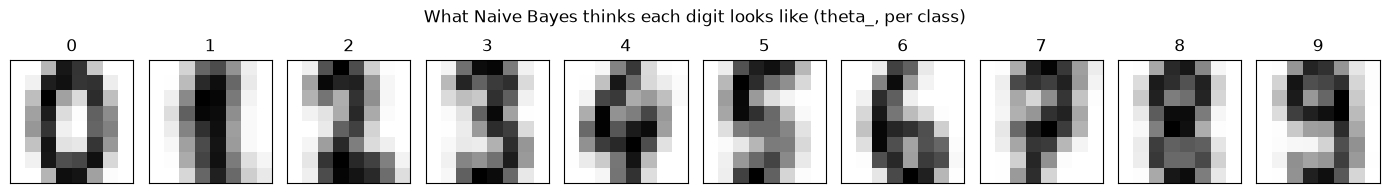

In [8]:
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for digit, ax in enumerate(axes.flat):
    ax.imshow(nb.theta_[digit].reshape(8, 8), cmap="gray_r")
    ax.set_title(str(digit))
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("What Naive Bayes thinks each digit looks like (theta_, per class)")
plt.tight_layout()
plt.show()

Nearly identical to notebook 1's mean-image picture from raw data. That's not a coincidence: `theta_` *is* the per-class mean, computed the same way, just stored as the model's parameters instead of a one-off plot.

No hyperparameters to tune, and both `fit` and `predict` are close to instantaneous, a useful, cheap baseline to compare more elaborate models against, even where its independence assumption is clearly wrong. On text, where words really are closer to independent given the topic, this gap tends to close.

### 3.1 The decision boundary, visually

On the synthetic moons data used for boundary pictures all week:

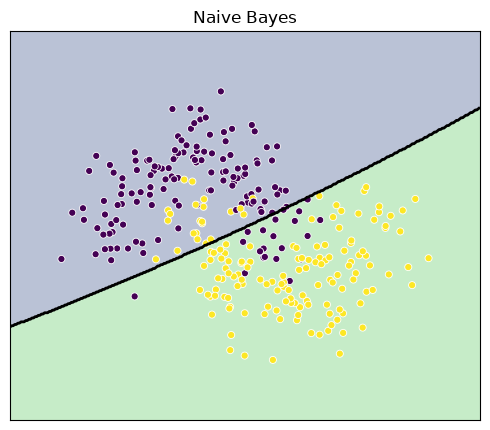

In [9]:
nb_moons = GaussianNB().fit(X_moons, y_moons)

fig, ax = plt.subplots(figsize=(5, 4.4))
plot_boundary(ax, nb_moons, X_moons, y_moons, "Naive Bayes")
plt.tight_layout()
plt.show()

Curved, not a straight line: each class's Gaussian blob bends naturally around the moon shape, without any kernel trick.

## 4. Summary

- Naive Bayes reasons about the problem probabilistically, applying Bayes' theorem with one simplifying assumption: every feature is independent of every other, given the class.
- Naive Bayes is a family (`MultinomialNB`, `GaussianNB`, `BernoulliNB`): same Bayes' theorem and independence assumption, a different distribution per feature type.
- What it learns per class is literally a mean and variance per feature (`theta_`), visibly the same as notebook 1's mean-image EDA.
- No meaningful hyperparameters to tune, and both `fit` and `predict` are close to instantaneous.
- The independence assumption is clearly false for neighboring image pixels, and accuracy shows it, a useful contrast with how well it's expected to do on text, where it's the classic algorithm behind spam filtering.

Notebook 5 puts all eight models from weeks 4 and 5 side by side, and closes the week with a summary and exercises.